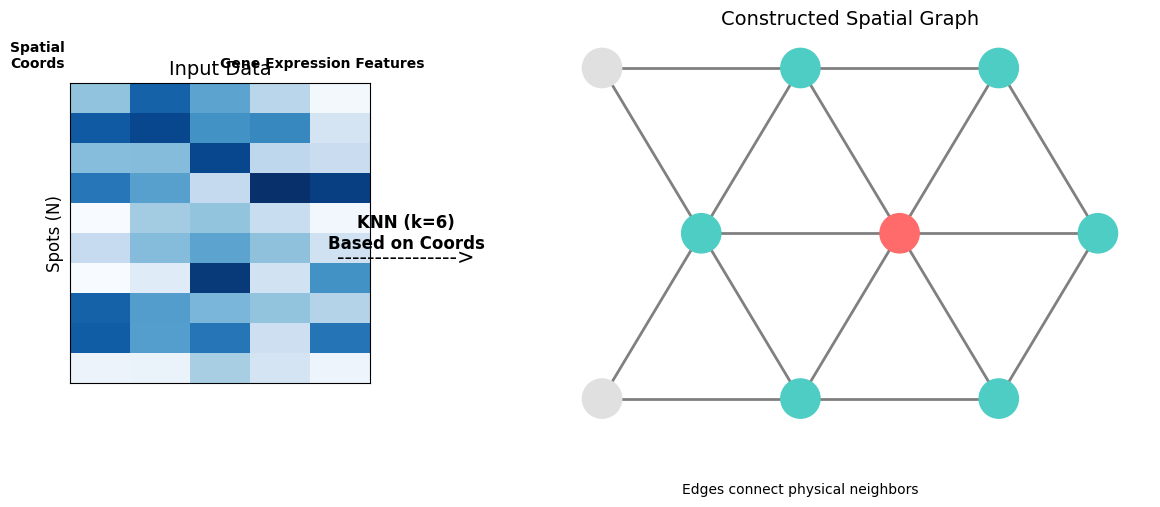

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

def draw_concept_diagram():
    fig = plt.figure(figsize=(12, 5))
    
    # --- 1. 左侧：绘制基因表达矩阵示意图 ---
    ax1 = fig.add_axes([0.05, 0.2, 0.25, 0.6]) # [left, bottom, width, height]
    
    # 模拟数据 (10个spot, 5个基因)
    data = np.random.rand(10, 5)
    # 模拟坐标列 (只是为了画图好看)
    coords_col = np.linspace(0, 1, 10).reshape(-1, 1)
    
    # 画基因数据热图
    ax1.imshow(data, aspect='auto', cmap='Blues', interpolation='nearest')
    
    # 画旁边的坐标列 (示意 x,y)
    # 这里用一种不同的颜色条来代表坐标数据
    ax1.text(-1.5, -1, "Spatial\nCoords", fontsize=10, fontweight='bold')
    ax1.text(2, -1, "Gene Expression Features", fontsize=10, fontweight='bold')
    
    # 加上边框和标签，使其看起来像矩阵
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_ylabel("Spots (N)", fontsize=12)
    ax1.set_title("Input Data", fontsize=14)
    
    # --- 2. 箭头 (Matplotlib 很难画漂亮的弯曲箭头，建议在 PPT 里加) ---
    fig.text(0.33, 0.5, "KNN (k=6)\nBased on Coords", ha='center', va='center', fontsize=12, fontweight='bold')
    fig.text(0.33, 0.45, "---------------->", ha='center', va='center', fontsize=15)

    # --- 3. 右侧：绘制六边形图结构 ---
    ax2 = fig.add_axes([0.45, 0.1, 0.5, 0.8])
    
    # 创建一个典型的 10x Visium 六边形布局
    G = nx.grid_2d_graph(3, 3) # 简单的网格，我们手动调整位置变成六边形
    pos = {}
    row_h = np.sqrt(3) / 2
    nodes = list(G.nodes())
    
    # 手动设置六边形坐标
    cnt = 0
    for r in range(3):
        for c in range(3):
            # 偶数行偏移
            x_offset = 0.5 if r % 2 != 0 else 0
            pos[nodes[cnt]] = (c + x_offset, r * row_h)
            cnt += 1
            if cnt >= len(nodes): break
            
    # 重新连接边以符合 k=6
    # 这里只是示意图，我们画一个完全连接的网格
    G_hex = nx.Graph()
    G_hex.add_nodes_from(nodes)
    
    # 简单的距离连接逻辑
    import math
    for n1 in nodes:
        for n2 in nodes:
            if n1 == n2: continue
            x1, y1 = pos[n1]
            x2, y2 = pos[n2]
            dist = math.sqrt((x1-x2)**2 + (y1-y2)**2)
            if dist < 1.1: # 阈值连接最近邻
                G_hex.add_edge(n1, n2)

    # 绘制
    # 选一个中心点变色
    node_colors = ['#E0E0E0'] * len(nodes)
    center_node_idx = 4 # 随便选个中间的
    node_colors[center_node_idx] = '#FF6B6B' # 红色
    
    # 获取邻居并变色
    neighbors = list(G_hex.neighbors(nodes[center_node_idx]))
    for i, n in enumerate(nodes):
        if n in neighbors:
            node_colors[i] = '#4ECDC4' # 绿色

    nx.draw(G_hex, pos, ax=ax2, 
            with_labels=False, 
            node_color=node_colors, 
            edge_color='gray', 
            node_size=800,
            width=2)
    
    # 在节点里画一点东西示意它是“Feature”
    ax2.set_title("Constructed Spatial Graph", fontsize=14)
    ax2.text(1, -0.5, "Edges connect physical neighbors", ha='center')

    plt.show()

draw_concept_diagram()

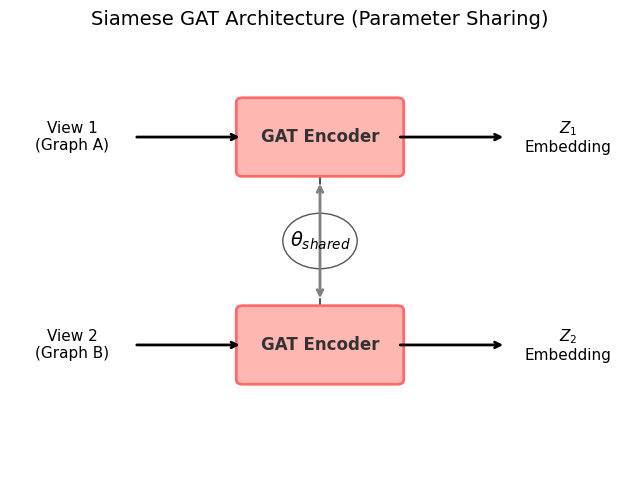

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_shared_gat():
    # 1. 设置画布
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')  # 关闭坐标轴

    # --- 颜色定义 ---
    color_gat = '#FFB7B2'      # 浅红色/橙色，代表模型
    color_input = '#E0E0E0'    # 浅灰色，代表输入
    color_output = '#B5EAD7'   # 浅绿色，代表输出 Z
    text_color = '#333333'

    # --- 2. 绘制 GAT 盒子 (上下两个) ---
    # 定义盒子位置
    box_width = 2.5
    box_height = 1.5
    x_pos = 3.75
    y_top = 6.5
    y_bottom = 2.0

    # 上方 GAT 盒子
    gat_box_top = patches.FancyBboxPatch(
        (x_pos, y_top), box_width, box_height,
        boxstyle="round,pad=0.1", 
        edgecolor='#FF6B6B', facecolor=color_gat, linewidth=2, zorder=2
    )
    ax.add_patch(gat_box_top)
    ax.text(x_pos + box_width/2, y_top + box_height/2, "GAT Encoder", 
            ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)

    # 下方 GAT 盒子
    gat_box_bottom = patches.FancyBboxPatch(
        (x_pos, y_bottom), box_width, box_height,
        boxstyle="round,pad=0.1", 
        edgecolor='#FF6B6B', facecolor=color_gat, linewidth=2, zorder=2
    )
    ax.add_patch(gat_box_bottom)
    ax.text(x_pos + box_width/2, y_bottom + box_height/2, "GAT Encoder", 
            ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)


    # --- 3. 绘制 "参数共享" (The Shared Link) ---
    # 在两个盒子中间画一个连接符
    center_x = x_pos + box_width / 2
    
    # 画一条虚线连接两个盒子
    ax.plot([center_x, center_x], [y_bottom + box_height + 0.1, y_top - 0.1], 
            color='#555555', linestyle='--', linewidth=1.5, zorder=1)
    
    # 画中间的圆圈 + 锁链含义
    circle = patches.Circle((center_x, 5.0), radius=0.6, color='white', ec='#555555', zorder=3)
    ax.add_patch(circle)
    
    # 在圆圈里写 Shared Theta
    ax.text(center_x, 5.0, r"$\theta_{shared}$", 
            ha='center', va='center', fontsize=14, fontweight='bold', color='black', zorder=4)
    
    # (可选) 画一个简单的"循环箭头"示意更新同步，或者双向箭头
    ax.annotate('', xy=(center_x, y_top - 0.2), xytext=(center_x, y_bottom + box_height + 0.2),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=2))


    # --- 4. 绘制输入输出流 (示意) ---
    
    # 输入 View 1 (左上)
    ax.text(1, y_top + box_height/2, "View 1\n(Graph A)", ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(x_pos, y_top + box_height/2), xytext=(2, y_top + box_height/2),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # 输入 View 2 (左下)
    ax.text(1, y_bottom + box_height/2, "View 2\n(Graph B)", ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(x_pos, y_bottom + box_height/2), xytext=(2, y_bottom + box_height/2),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # 输出 Z1 (右上)
    ax.text(9, y_top + box_height/2, r"$Z_1$" + "\nEmbedding", ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(8, y_top + box_height/2), xytext=(x_pos + box_width, y_top + box_height/2),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # 输出 Z2 (右下)
    ax.text(9, y_bottom + box_height/2, r"$Z_2$" + "\nEmbedding", ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(8, y_bottom + box_height/2), xytext=(x_pos + box_width, y_bottom + box_height/2),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # 标题
    plt.title("Siamese GAT Architecture (Parameter Sharing)", fontsize=14, y=0.95)
    
    plt.show()

if __name__ == "__main__":
    draw_shared_gat()

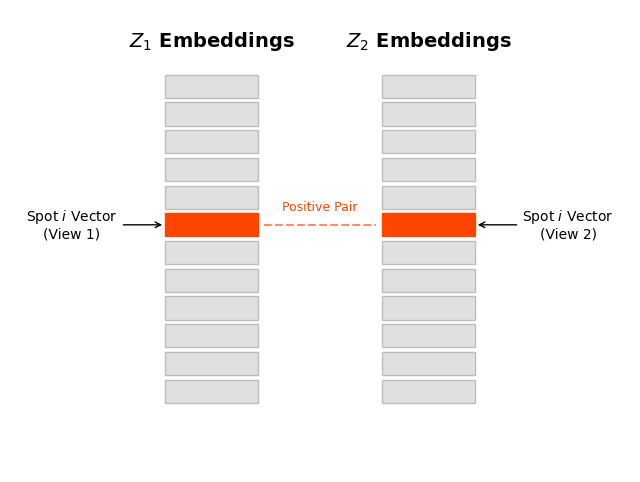

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_embedding_layer():
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # --- 参数设置 ---
    num_spots = 12          # 示意图里画多少层
    highlight_idx = 6       # 第几个 Spot 被高亮 (从下往上数，0开始)
    
    col_width = 1.5         # 柱子宽度
    row_height = 0.5        # 每一行的高度
    spacing_y = 0.1         # 行间距
    
    z1_x = 2.5              # Z1 柱子的左侧 X 坐标
    z2_x = 6.0              # Z2 柱子的左侧 X 坐标
    start_y = 1.5           # 起始 Y 坐标

    # 颜色
    base_color = '#E0E0E0'     # 浅灰色 (其他 Spots)
    highlight_color = '#FF4500' # 亮红色/橙红色 (目标 Spot i)
    border_color = '#BDBDBD'   # 边框颜色

    # --- 绘图循环函数 ---
    def draw_column(x_start, label_text):
        current_y = start_y
        # 画标题
        ax.text(x_start + col_width/2, start_y + num_spots*(row_height+spacing_y) + 0.5, 
                label_text, ha='center', fontsize=14, fontweight='bold')
        
        # 循环画每一层
        for i in range(num_spots):
            # 判断是否是需要高亮的层
            if i == highlight_idx:
                face_c = highlight_color
                edge_c = highlight_color # 高亮时边框也同色，更醒目
                zorder = 10 # 让它浮在最上面
            else:
                face_c = base_color
                edge_c = border_color
                zorder = 1
            
            # 绘制矩形条
            rect = patches.Rectangle(
                (x_start, current_y), col_width, row_height,
                linewidth=1, edgecolor=edge_c, facecolor=face_c, zorder=zorder
            )
            ax.add_patch(rect)
            current_y += row_height + spacing_y
        return current_y

    # --- 执行绘制 ---
    # 画 Z1
    top_y = draw_column(z1_x, r"$Z_1$ Embeddings")
    # 画 Z2
    draw_column(z2_x, r"$Z_2$ Embeddings")


    # --- 添加注释辅助线 (可选，增强说明性) ---
    # 计算高亮条的中心 Y 坐标
    highlight_y_center = start_y + highlight_idx * (row_height + spacing_y) + row_height / 2
    
    # 左侧注释
    ax.annotate('Spot $i$ Vector\n(View 1)', 
                xy=(z1_x, highlight_y_center), 
                xytext=(z1_x - 1.5, highlight_y_center),
                arrowprops=dict(arrowstyle='->', color='black'),
                va='center', ha='center', fontsize=10)
    
    # 右侧注释
    ax.annotate('Spot $i$ Vector\n(View 2)', 
                xy=(z2_x + col_width, highlight_y_center), 
                xytext=(z2_x + col_width + 1.5, highlight_y_center),
                arrowprops=dict(arrowstyle='->', color='black'),
                va='center', ha='center', fontsize=10)

    # 中间连接虚线 (暗示它们是一对)
    ax.plot([z1_x + col_width + 0.1, z2_x - 0.1], 
            [highlight_y_center, highlight_y_center], 
            color=highlight_color, linestyle='--', linewidth=1.5, alpha=0.6)
    ax.text((z1_x + col_width + z2_x)/2, highlight_y_center + 0.3, "Positive Pair", 
            ha='center', color=highlight_color, fontsize=9)

    # 整体标题
    # plt.title("Representation Layer Output", y=1.05)
    plt.show()

if __name__ == "__main__":
    draw_embedding_layer()

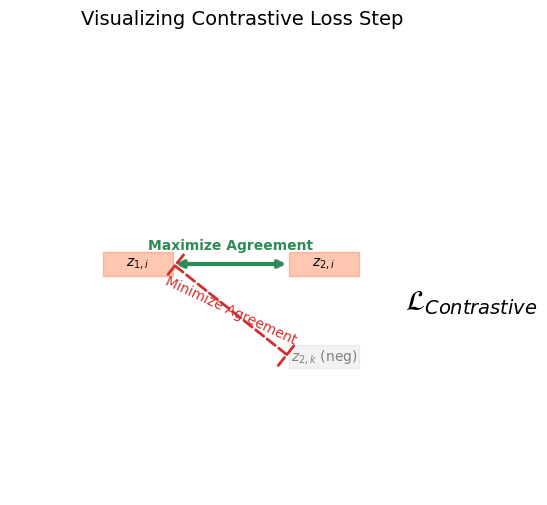

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_contrastive_mechanism():
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # 定义位置
    z1_x = 2
    z2_x = 6
    spot_y = 5  # 红色条的高度
    
    # 1. 模拟画出 Z1 和 Z2 的红色条 (为了定位，实际你已有图)
    # Z1 Red Bar
    rect1 = patches.Rectangle((z1_x, spot_y-0.25), 1.5, 0.5, color='#FF4500', alpha=0.3)
    ax.add_patch(rect1)
    ax.text(z1_x+0.75, spot_y, r"$z_{1,i}$", ha='center', va='center', fontweight='bold')

    # Z2 Red Bar
    rect2 = patches.Rectangle((z2_x, spot_y-0.25), 1.5, 0.5, color='#FF4500', alpha=0.3)
    ax.add_patch(rect2)
    ax.text(z2_x+0.75, spot_y, r"$z_{2,i}$", ha='center', va='center', fontweight='bold')

    # Z2 Negative Bar (干扰项)
    neg_y = 3
    rect_neg = patches.Rectangle((z2_x, neg_y-0.25), 1.5, 0.5, color='gray', alpha=0.1)
    ax.add_patch(rect_neg)
    ax.text(z2_x+0.75, neg_y, r"$z_{2,k}$ (neg)", ha='center', va='center', color='gray')


    # --- 核心：对比学习连线 ---

    # 1. Positive Pair (拉近 - 绿色实线)
    ax.annotate('', 
                xy=(z2_x, spot_y), 
                xytext=(z1_x + 1.5, spot_y),
                arrowprops=dict(arrowstyle='<->', color='#2E8B57', lw=3))
    
    ax.text((z1_x + 1.5 + z2_x)/2, spot_y + 0.3, "Maximize Agreement", 
            ha='center', color='#2E8B57', fontsize=10, fontweight='bold')

    # 2. Negative Pair (推远 - 红色虚线)
    # 从 Z1 Red 连向 Z2 Gray
    ax.annotate('', 
                xy=(z2_x, neg_y), 
                xytext=(z1_x + 1.5, spot_y),
                arrowprops=dict(arrowstyle='|-|', color='#D32F2F', lw=2, linestyle='--'))
    
    ax.text((z1_x + 1.5 + z2_x)/2, (spot_y + neg_y)/2, "Minimize Agreement", 
            ha='center', va='center', color='#D32F2F', fontsize=10, rotation=-25)

    # 3. Loss 符号
    ax.text(8.5, 4, r"$\mathcal{L}_{Contrastive}$", fontsize=20)
    
    plt.title("Visualizing Contrastive Loss Step", fontsize=14)
    plt.show()

if __name__ == "__main__":
    draw_contrastive_mechanism()

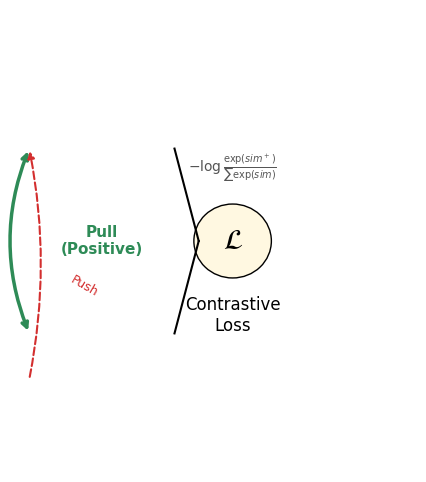

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_loss_function_module():
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # 定义接入口坐标 (假设这是你现有图 Z1 Z2 的右侧边缘)
    # 你在拼图时，把这部分拼在 image_e623c7.png 的右边
    input_x = 0
    z1_y = 7.0  # 对应 Z1 红色条的大概高度
    z2_y = 3.0  # 对应 Z2 红色条的大概高度
    
    # 1. 绘制“拉近”线 (Pull Positive)
    # 画一条显眼的绿色连接线
    ax.annotate("", 
                xy=(input_x, z1_y), 
                xytext=(input_x, z2_y),
                arrowprops=dict(arrowstyle="<->", connectionstyle="arc3,rad=-0.2", 
                                color="#2E8B57", lw=2.5, linestyle='-'))
    
    # 标注 "Maximize Agreement"
    ax.text(1.5, 5.0, "Pull\n(Positive)", ha='center', va='center', 
            color='#2E8B57', fontsize=11, fontweight='bold')

    # 2. 绘制“推远”线 (Push Negative) - 示意性
    # 假设 Z2 的其他位置有负样本
    neg_y = 2.0
    ax.annotate("", 
                xy=(input_x, z1_y), 
                xytext=(input_x, neg_y),
                arrowprops=dict(arrowstyle="-|>", connectionstyle="arc3,rad=0.1", 
                                color="#D32F2F", lw=1.5, linestyle='--'))
    ax.text(0.8, 3.8, "Push", color='#D32F2F', fontsize=9, rotation=-30)

    # 3. 绘制最终的 Loss 汇聚符号
    # 画一个大括号或者汇聚线
    ax.plot([3, 3.5], [z1_y, 5], color='black', lw=1.5) # 上半部
    ax.plot([3, 3.5], [z2_y, 5], color='black', lw=1.5) # 下半部
    
    # Loss 圆圈
    circle = patches.Circle((4.2, 5), radius=0.8, facecolor='#FFF8E1', edgecolor='black')
    ax.add_patch(circle)
    ax.text(4.2, 5, r"$\mathcal{L}$", fontsize=20, ha='center', va='center', fontweight='bold')
    
    # Loss 标签
    ax.text(4.2, 3.8, "Contrastive\nLoss", ha='center', va='top', fontsize=12)
    
    # (可选) 加上公式
    formula = r"$-\log \frac{\exp(sim^+)}{\sum \exp(sim)}$"
    ax.text(4.2, 6.5, formula, ha='center', fontsize=10, color='#555')

    plt.show()

if __name__ == "__main__":
    draw_loss_function_module()

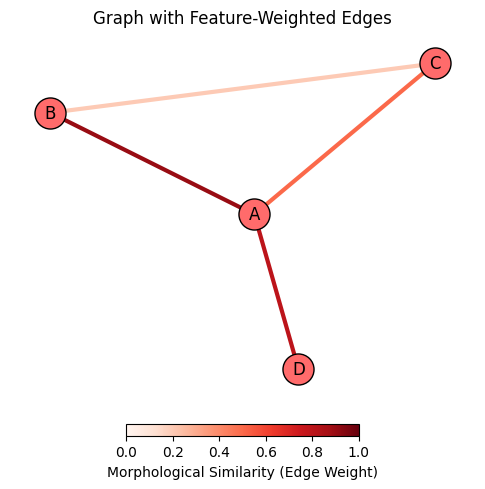

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_weighted_graph():
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 1. 创建图
    G = nx.Graph()
    # 添加边和权重 (模拟相似度 0~1)
    edges = [('A', 'B', 0.9), ('B', 'C', 0.2), ('C', 'A', 0.5), ('A', 'D', 0.8)]
    G.add_weighted_edges_from(edges)
    
    pos = nx.spring_layout(G)
    
    # 2. 提取权重用于颜色映射
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    
    # 3. 绘制节点
    nx.draw_networkx_nodes(G, pos, node_color='#FF6B6B', node_size=500, edgecolors='black')
    
    # 4. 绘制边 - 核心步骤！
    # edge_cmap: 颜色表 (plt.cm.Reds, plt.cm.Greys, plt.cm.Blues)
    # edge_color: 传入数值列表，它会自动映射
    edges_draw = nx.draw_networkx_edges(
        G, pos, 
        edge_color=weights, 
        edge_cmap=plt.cm.Reds,  # 红色渐变：浅红 -> 深红
        edge_vmin=0, 
        edge_vmax=1, 
        width=3  # 线条稍微粗一点才能看清颜色
    )
    
    # 5. 添加颜色条 (Colorbar) - 这就是你要的“形状”
    # 这是一个专门的技巧，用来给 NetworkX 的边加 Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.5, pad=0.05)
    cbar.set_label('Morphological Similarity (Edge Weight)', fontsize=10)

    # 标签
    nx.draw_networkx_labels(G, pos)
    
    plt.axis('off')
    plt.title("Graph with Feature-Weighted Edges")
    plt.show()

if __name__ == "__main__":
    draw_weighted_graph()

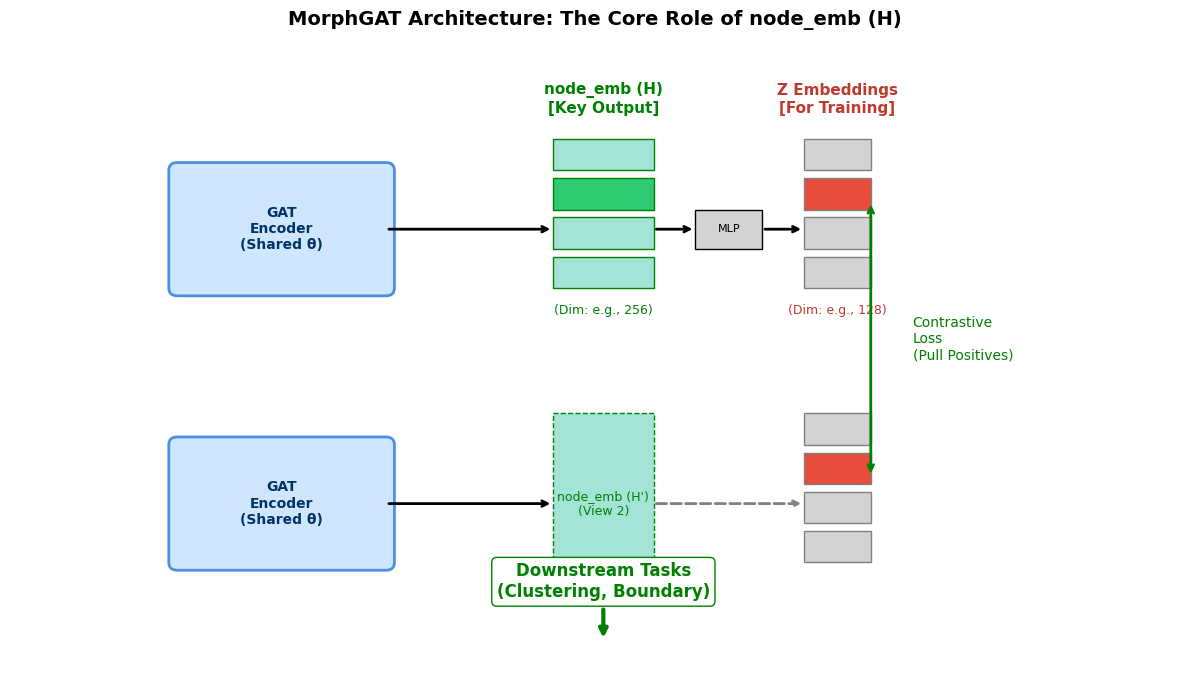

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_architecture_concept_en():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # --- Styles ---
    box_style = dict(boxstyle="round,pad=0.3", ec="black", lw=2)
    arrow_props = dict(arrowstyle="->", lw=2, color="black")
    downstream_arrow = dict(arrowstyle="-|>", lw=3, color="green")
    
    # --- 1. Draw GAT Encoder (Blue Box) ---
    # Top Encoder
    gat_enc_top = patches.FancyBboxPatch((2, 5), 2.5, 1.5, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(gat_enc_top)
    ax.text(3.25, 5.75, "GAT\nEncoder\n(Shared θ)", ha='center', va='center', fontsize=10, fontweight='bold', color="#003366")

    # Bottom Encoder
    gat_enc_bot = patches.FancyBboxPatch((2, 1.5), 2.5, 1.5, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(gat_enc_bot)
    ax.text(3.25, 2.25, "GAT\nEncoder\n(Shared θ)", ha='center', va='center', fontsize=10, fontweight='bold', color="#003366")

    # --- 2. Draw node_emb (H) - The Key Part (Green, Wider) ---
    h_x_start = 6.5
    h_width = 1.2
    h_height = 0.4
    h_gap = 0.1

    # Top H stack
    for i in range(4):
        color = "#2ECC71" if i == 2 else "#A3E4D7" # Highlight one
        rect = patches.Rectangle((h_x_start, 5 + i*(h_height+h_gap)), h_width, h_height, linewidth=1, edgecolor='green', facecolor=color)
        ax.add_patch(rect)
    
    # English Text for H
    ax.text(h_x_start + h_width/2, 7.2, "node_emb (H)\n[Key Output]", ha='center', va='bottom', fontsize=11, fontweight='bold', color="green")
    ax.text(h_x_start + h_width/2, 4.8, "(Dim: e.g., 256)", ha='center', va='top', fontsize=9, color="green")

    # Bottom H stack (Simplified)
    rect_h_bot = patches.Rectangle((h_x_start, 1.5), h_width, 4*(h_height+h_gap)-h_gap, linewidth=1, edgecolor='green', facecolor="#A3E4D7", linestyle="--")
    ax.add_patch(rect_h_bot)
    ax.text(h_x_start + h_width/2, 2.25, "node_emb (H')\n(View 2)", ha='center', va='center', fontsize=9, color="green")

    # --- 3. Draw Z Embeddings (Red/Grey, Narrower) ---
    z_x_start = 9.5
    z_width = 0.8 # Narrower than H
    z_height = 0.4
    z_gap = 0.1

    # Z1 (Top)
    for i in range(4):
        color = "#E74C3C" if i == 2 else "#D3D3D3" # Highlight one
        rect = patches.Rectangle((z_x_start, 5 + i*(z_height+z_gap)), z_width, z_height, linewidth=1, edgecolor='grey', facecolor=color)
        ax.add_patch(rect)
    
    # English Text for Z
    ax.text(z_x_start + z_width/2, 7.2, "Z Embeddings\n[For Training]", ha='center', va='bottom', fontsize=11, fontweight='bold', color="#C0392B")
    ax.text(z_x_start + z_width/2, 4.8, "(Dim: e.g., 128)", ha='center', va='top', fontsize=9, color="#C0392B")

    # Z2 (Bottom)
    for i in range(4):
        color = "#E74C3C" if i == 2 else "#D3D3D3"
        rect = patches.Rectangle((z_x_start, 1.5 + i*(z_height+z_gap)), z_width, z_height, linewidth=1, edgecolor='grey', facecolor=color)
        ax.add_patch(rect)

    # --- 4. Draw Connections ---
    # Encoder -> H
    ax.annotate("", xy=(h_x_start, 5.75), xytext=(4.5, 5.75), arrowprops=arrow_props)
    ax.annotate("", xy=(h_x_start, 2.25), xytext=(4.5, 2.25), arrowprops=arrow_props)

    # H -> Z (with small MLP Projection Head)
    proj_box_top = patches.Rectangle((8.2, 5.5), 0.8, 0.5, fc='lightgrey', ec='black')
    ax.add_patch(proj_box_top)
    ax.text(8.6, 5.75, "MLP", ha='center', va='center', fontsize=8)
    
    ax.annotate("", xy=(8.2, 5.75), xytext=(h_x_start+h_width, 5.75), arrowprops=arrow_props)
    ax.annotate("", xy=(z_x_start, 5.75), xytext=(9.0, 5.75), arrowprops=arrow_props)
    
    # Bottom H->Z arrow (simplified)
    ax.annotate("", xy=(z_x_start, 2.25), xytext=(h_x_start+h_width, 2.25), arrowprops=dict(arrowstyle="->", lw=2, color="grey", ls="--"))

    # --- 5. Loss & Downstream Arrows ---
    # Contrastive Loss (Right Side)
    ax.annotate("", xy=(z_x_start+z_width, 6.1), xytext=(z_x_start+z_width, 2.6), arrowprops=dict(arrowstyle="<->", lw=2, color="green"))
    ax.text(z_x_start+z_width+0.5, 4.35, "Contrastive\nLoss\n(Pull Positives)", ha='left', va='center', color="green")

    # ★★★ Downstream Tasks Arrow (From H) ★★★
    ax.annotate("Downstream Tasks\n(Clustering, Boundary)", xy=(h_x_start + h_width/2, 0.5), xytext=(h_x_start + h_width/2, 1.5),
                arrowprops=downstream_arrow, ha='center', va='top', fontsize=12, fontweight='bold', color="green", bbox=dict(boxstyle="round", fc="white", ec="green"))

    # --- Title ---
    ax.set_title("MorphGAT Architecture: The Core Role of node_emb (H)", fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

draw_architecture_concept_en()

/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/home/wangzz_group/zhaipengyuan/.conda/envs/BEPH/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/wangzz_group/zhaipengyuan/.conda/envs/BEPH/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph

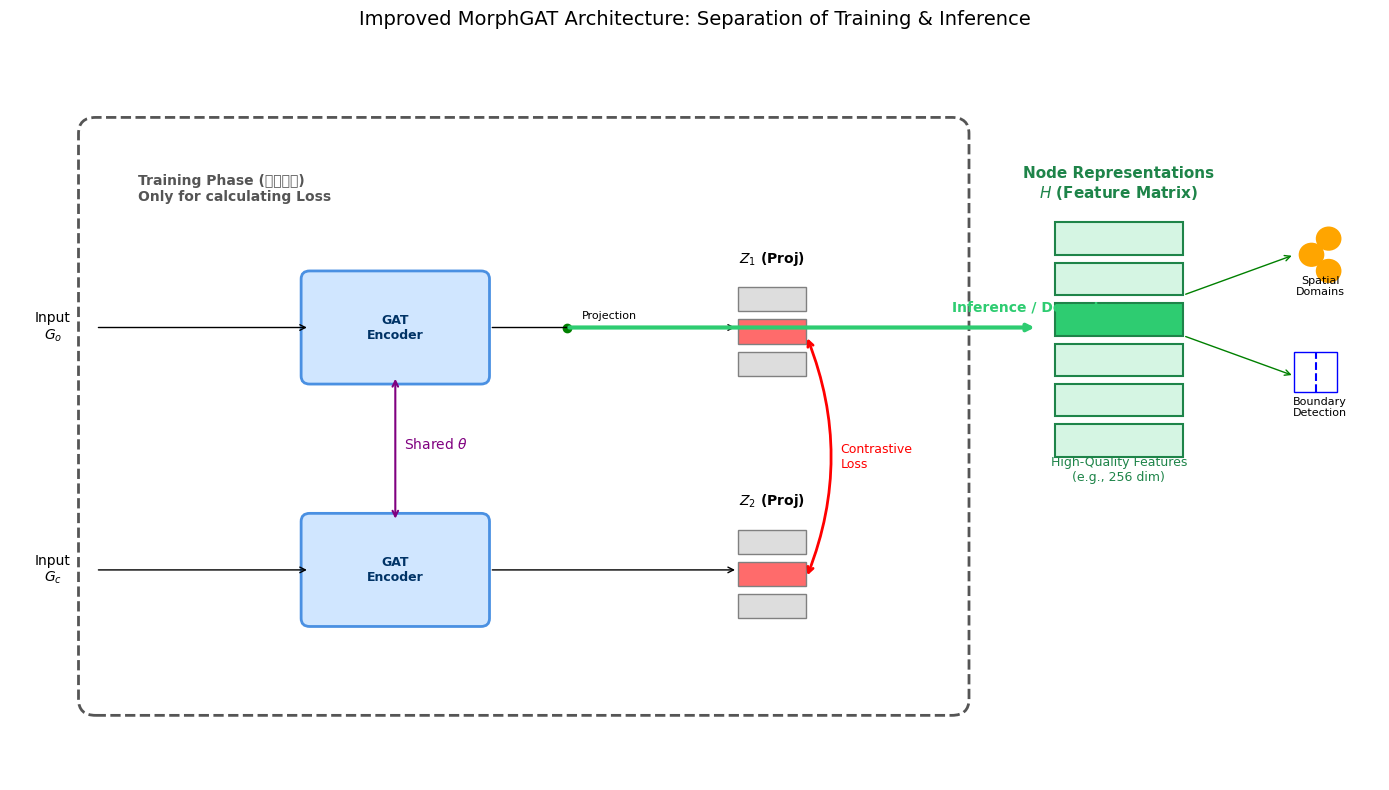

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_new_layout():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis('off')

    # --- 1. 画主训练框 (Training Phase) ---
    # 使用圆角矩形，灰色边框
    main_box = patches.FancyBboxPatch((1, 1), 10, 7, boxstyle="round,pad=0.2", 
                                      ec="#555555", fc="none", lw=2, linestyle="--")
    ax.add_patch(main_box)
    ax.text(1.5, 7.5, "Training Phase (训练阶段)\nOnly for calculating Loss", 
            ha='left', va='top', fontsize=10, color="#555555", fontweight='bold')

    # --- 2. 内部组件：Encoder & Z ---
    
    # GAT Encoders (Blue)
    # Top
    enc_top = patches.FancyBboxPatch((3.5, 5), 2, 1.2, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(enc_top)
    ax.text(4.5, 5.6, "GAT\nEncoder", ha='center', va='center', fontsize=9, fontweight='bold', color="#003366")
    
    # Bottom
    enc_bot = patches.FancyBboxPatch((3.5, 2), 2, 1.2, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(enc_bot)
    ax.text(4.5, 2.6, "GAT\nEncoder", ha='center', va='center', fontsize=9, fontweight='bold', color="#003366")

    # Shared Parameters
    ax.annotate("", xy=(4.5, 5), xytext=(4.5, 3.2), arrowprops=dict(arrowstyle="<->", lw=1.5, color="purple"))
    ax.text(4.6, 4.1, "Shared $\\theta$", color="purple", fontsize=10)

    # Z Embeddings (Red/Grey - Inside the box)
    z_x = 8.5
    # Z1
    for i in range(3):
        col = "#FF6B6B" if i==1 else "#DDDDDD"
        rect = patches.Rectangle((z_x, 5 + i*0.4), 0.8, 0.3, ec="gray", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.4, 6.4, "$Z_1$ (Proj)", ha='center', fontsize=10, fontweight='bold')
    
    # Z2
    for i in range(3):
        col = "#FF6B6B" if i==1 else "#DDDDDD"
        rect = patches.Rectangle((z_x, 2 + i*0.4), 0.8, 0.3, ec="gray", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.4, 3.4, "$Z_2$ (Proj)", ha='center', fontsize=10, fontweight='bold')

    # Loss Arrows
    ax.annotate("", xy=(z_x+0.8, 5.5), xytext=(z_x+0.8, 2.5), arrowprops=dict(arrowstyle="<->", connectionstyle="arc3,rad=0.2", color="red", lw=2))
    ax.text(z_x+1.2, 4.0, "Contrastive\nLoss", va='center', color="red", fontsize=9)

    # --- 3. 关键连接：分叉线 ---
    # 从 Encoder 出来，分两路
    # Top Path
    ax.annotate("", xy=(z_x, 5.6), xytext=(5.6, 5.6), arrowprops=dict(arrowstyle="->", color="black")) # To Z
    ax.text(7.0, 5.7, "Projection", fontsize=8, ha='center')
    
    # Bottom Path
    ax.annotate("", xy=(z_x, 2.6), xytext=(5.6, 2.6), arrowprops=dict(arrowstyle="->", color="black")) # To Z

    # --- 4. 框外组件：H Output (推理阶段) ---
    
    # 画一条“突破框”的线
    # 既然我们只关心原图的 H 用于推理，我们从上面的 Encoder 引出
    
    # 绘制 "分流点"
    plt.plot(6.5, 5.6, 'o', color='green', markersize=6) 
    
    # 绘制穿越线 (Thick Green Arrow)
    ax.annotate("", xy=(12, 5.6), xytext=(6.5, 5.6), 
                arrowprops=dict(arrowstyle="-|>", lw=3, color="#2ECC71"))
    
    ax.text(11, 5.8, "Inference / Downstream", color="#2ECC71", fontweight='bold', fontsize=10)

    # 绘制 H 矩阵 (Outside)
    h_x = 12.2
    for i in range(6):
        col = "#2ECC71" if i==3 else "#D5F5E3" # Green theme
        rect = patches.Rectangle((h_x, 4.0 + i*0.5), 1.5, 0.4, ec="#1E8449", fc=col, lw=1.5)
        ax.add_patch(rect)
    
    ax.text(h_x + 0.75, 7.2, "Node Representations\n$H$ (Feature Matrix)", ha='center', fontsize=11, fontweight='bold', color="#1E8449")
    ax.text(h_x + 0.75, 3.7, "High-Quality Features\n(e.g., 256 dim)", ha='center', fontsize=9, color="#1E8449")

    # --- 5. 下游任务图标 ---
    
    # Clustering
    ax.annotate("", xy=(15, 6.5), xytext=(h_x+1.5, 6.0), arrowprops=dict(arrowstyle="->", color="green"))
    circle1 = patches.Circle((15.2, 6.5), 0.15, fc="orange")
    circle2 = patches.Circle((15.4, 6.7), 0.15, fc="orange")
    circle3 = patches.Circle((15.4, 6.3), 0.15, fc="orange")
    ax.add_patch(circle1); ax.add_patch(circle2); ax.add_patch(circle3)
    ax.text(15.3, 6.0, "Spatial\nDomains", ha='center', fontsize=8)

    # Boundary
    ax.annotate("", xy=(15, 5.0), xytext=(h_x+1.5, 5.5), arrowprops=dict(arrowstyle="->", color="green"))
    rect_b = patches.Rectangle((15.0, 4.8), 0.5, 0.5, fc="none", ec="blue")
    ax.add_patch(rect_b)
    plt.plot([15.25, 15.25], [4.8, 5.3], 'b--') # boundary line
    ax.text(15.3, 4.5, "Boundary\nDetection", ha='center', fontsize=8)

    # --- 6. 输入占位符 ---
    ax.text(0.5, 5.6, "Input\n$G_o$", ha='center', va='center')
    ax.annotate("", xy=(3.5, 5.6), xytext=(1.0, 5.6), arrowprops=dict(arrowstyle="->"))

    ax.text(0.5, 2.6, "Input\n$G_c$", ha='center', va='center')
    ax.annotate("", xy=(3.5, 2.6), xytext=(1.0, 2.6), arrowprops=dict(arrowstyle="->"))

    ax.set_title("Improved MorphGAT Architecture: Separation of Training & Inference", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

draw_new_layout()

/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2787407171.py:113: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


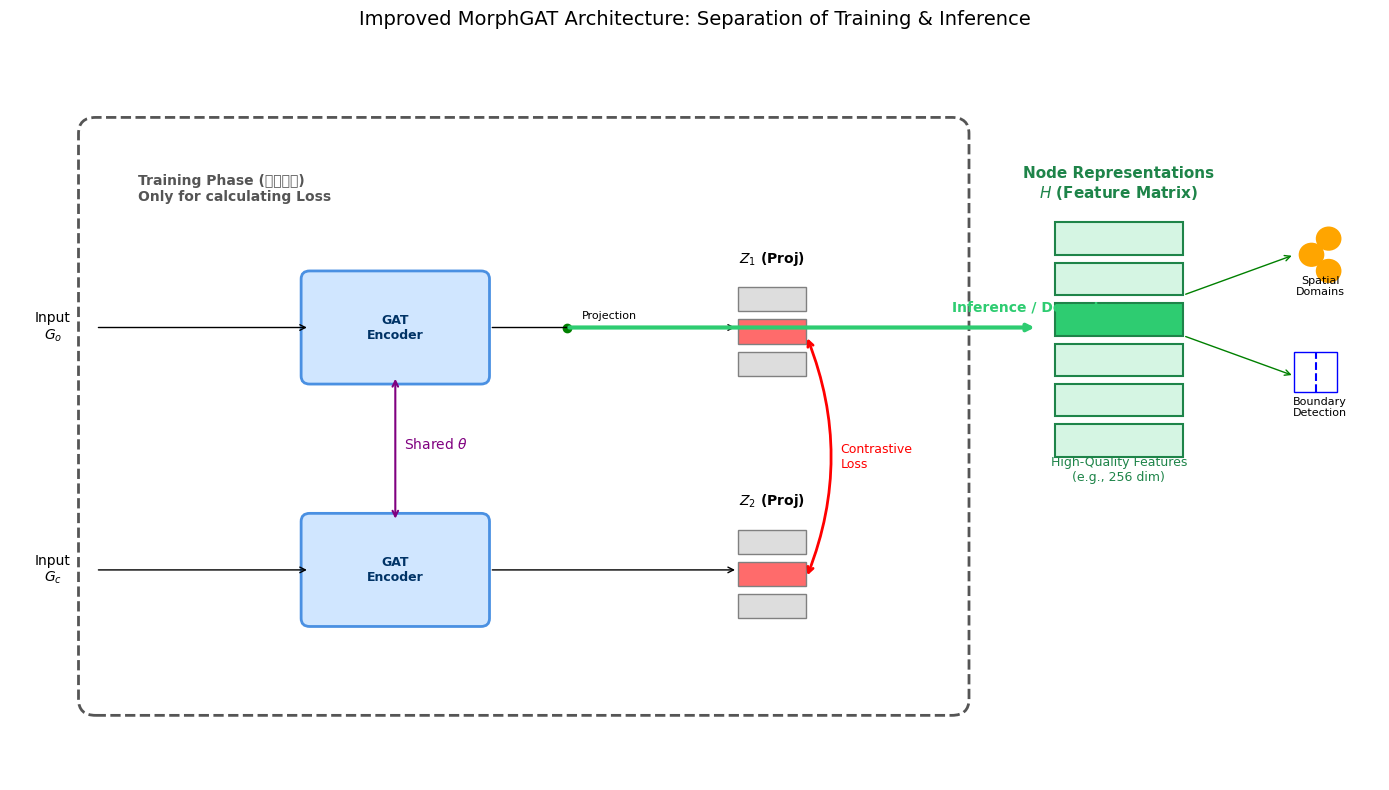

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_new_layout():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis('off')

    # --- 1. 画主训练框 (Training Phase) ---
    # 使用圆角矩形，灰色边框
    main_box = patches.FancyBboxPatch((1, 1), 10, 7, boxstyle="round,pad=0.2", 
                                      ec="#555555", fc="none", lw=2, linestyle="--")
    ax.add_patch(main_box)
    ax.text(1.5, 7.5, "Training Phase (训练阶段)\nOnly for calculating Loss", 
            ha='left', va='top', fontsize=10, color="#555555", fontweight='bold')

    # --- 2. 内部组件：Encoder & Z ---
    
    # GAT Encoders (Blue)
    # Top
    enc_top = patches.FancyBboxPatch((3.5, 5), 2, 1.2, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(enc_top)
    ax.text(4.5, 5.6, "GAT\nEncoder", ha='center', va='center', fontsize=9, fontweight='bold', color="#003366")
    
    # Bottom
    enc_bot = patches.FancyBboxPatch((3.5, 2), 2, 1.2, boxstyle="round,pad=0.1", ec="#4A90E2", fc="#D0E6FF", lw=2)
    ax.add_patch(enc_bot)
    ax.text(4.5, 2.6, "GAT\nEncoder", ha='center', va='center', fontsize=9, fontweight='bold', color="#003366")

    # Shared Parameters
    ax.annotate("", xy=(4.5, 5), xytext=(4.5, 3.2), arrowprops=dict(arrowstyle="<->", lw=1.5, color="purple"))
    ax.text(4.6, 4.1, "Shared $\\theta$", color="purple", fontsize=10)

    # Z Embeddings (Red/Grey - Inside the box)
    z_x = 8.5
    # Z1
    for i in range(3):
        col = "#FF6B6B" if i==1 else "#DDDDDD"
        rect = patches.Rectangle((z_x, 5 + i*0.4), 0.8, 0.3, ec="gray", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.4, 6.4, "$Z_1$ (Proj)", ha='center', fontsize=10, fontweight='bold')
    
    # Z2
    for i in range(3):
        col = "#FF6B6B" if i==1 else "#DDDDDD"
        rect = patches.Rectangle((z_x, 2 + i*0.4), 0.8, 0.3, ec="gray", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.4, 3.4, "$Z_2$ (Proj)", ha='center', fontsize=10, fontweight='bold')

    # Loss Arrows
    ax.annotate("", xy=(z_x+0.8, 5.5), xytext=(z_x+0.8, 2.5), arrowprops=dict(arrowstyle="<->", connectionstyle="arc3,rad=0.2", color="red", lw=2))
    ax.text(z_x+1.2, 4.0, "Contrastive\nLoss", va='center', color="red", fontsize=9)

    # --- 3. 关键连接：分叉线 ---
    # 从 Encoder 出来，分两路
    # Top Path
    ax.annotate("", xy=(z_x, 5.6), xytext=(5.6, 5.6), arrowprops=dict(arrowstyle="->", color="black")) # To Z
    ax.text(7.0, 5.7, "Projection", fontsize=8, ha='center')
    
    # Bottom Path
    ax.annotate("", xy=(z_x, 2.6), xytext=(5.6, 2.6), arrowprops=dict(arrowstyle="->", color="black")) # To Z

    # --- 4. 框外组件：H Output (推理阶段) ---
    
    # 画一条“突破框”的线
    # 既然我们只关心原图的 H 用于推理，我们从上面的 Encoder 引出
    
    # 绘制 "分流点"
    plt.plot(6.5, 5.6, 'o', color='green', markersize=6) 
    
    # 绘制穿越线 (Thick Green Arrow)
    ax.annotate("", xy=(12, 5.6), xytext=(6.5, 5.6), 
                arrowprops=dict(arrowstyle="-|>", lw=3, color="#2ECC71"))
    
    ax.text(11, 5.8, "Inference / Downstream", color="#2ECC71", fontweight='bold', fontsize=10)

    # 绘制 H 矩阵 (Outside)
    h_x = 12.2
    for i in range(6):
        col = "#2ECC71" if i==3 else "#D5F5E3" # Green theme
        rect = patches.Rectangle((h_x, 4.0 + i*0.5), 1.5, 0.4, ec="#1E8449", fc=col, lw=1.5)
        ax.add_patch(rect)
    
    ax.text(h_x + 0.75, 7.2, "Node Representations\n$H$ (Feature Matrix)", ha='center', fontsize=11, fontweight='bold', color="#1E8449")
    ax.text(h_x + 0.75, 3.7, "High-Quality Features\n(e.g., 256 dim)", ha='center', fontsize=9, color="#1E8449")

    # --- 5. 下游任务图标 ---
    
    # Clustering
    ax.annotate("", xy=(15, 6.5), xytext=(h_x+1.5, 6.0), arrowprops=dict(arrowstyle="->", color="green"))
    circle1 = patches.Circle((15.2, 6.5), 0.15, fc="orange")
    circle2 = patches.Circle((15.4, 6.7), 0.15, fc="orange")
    circle3 = patches.Circle((15.4, 6.3), 0.15, fc="orange")
    ax.add_patch(circle1); ax.add_patch(circle2); ax.add_patch(circle3)
    ax.text(15.3, 6.0, "Spatial\nDomains", ha='center', fontsize=8)

    # Boundary
    ax.annotate("", xy=(15, 5.0), xytext=(h_x+1.5, 5.5), arrowprops=dict(arrowstyle="->", color="green"))
    rect_b = patches.Rectangle((15.0, 4.8), 0.5, 0.5, fc="none", ec="blue")
    ax.add_patch(rect_b)
    plt.plot([15.25, 15.25], [4.8, 5.3], 'b--') # boundary line
    ax.text(15.3, 4.5, "Boundary\nDetection", ha='center', fontsize=8)

    # --- 6. 输入占位符 ---
    ax.text(0.5, 5.6, "Input\n$G_o$", ha='center', va='center')
    ax.annotate("", xy=(3.5, 5.6), xytext=(1.0, 5.6), arrowprops=dict(arrowstyle="->"))

    ax.text(0.5, 2.6, "Input\n$G_c$", ha='center', va='center')
    ax.annotate("", xy=(3.5, 2.6), xytext=(1.0, 2.6), arrowprops=dict(arrowstyle="->"))

    ax.set_title("Improved MorphGAT Architecture: Separation of Training & Inference", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

draw_new_layout()

/tmp/ipykernel_4048906/2848856971.py:118: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2848856971.py:118: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2848856971.py:118: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4048906/2848856971.py:118: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


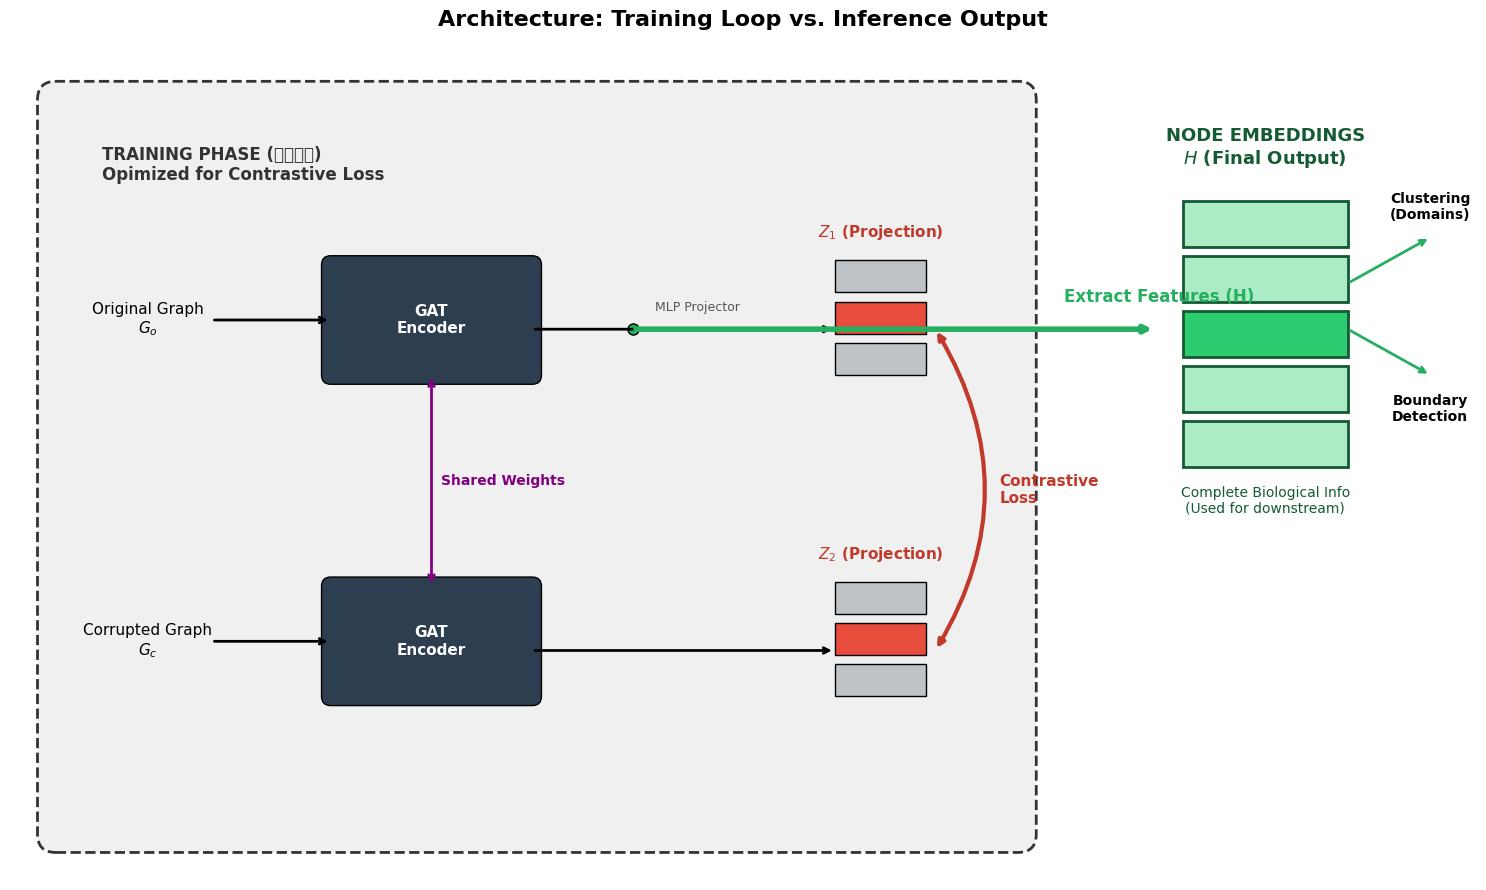

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_high_contrast_layout():
    # 设置画布，增加 DPI 让图像更清晰
    fig, ax = plt.subplots(figsize=(15, 9), dpi=100)
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis('off')

    # --- 配色方案 (Professional Palette) ---
    c_bg_box = "#F0F0F0"      # 训练框背景色 (浅灰)
    c_border = "#333333"      # 边框深色
    c_encoder = "#2c3e50"     # Encoder 深蓝 (稳重)
    c_text_white = "#ffffff"  # 白色文字
    c_text_dark = "#000000"   # 黑色文字
    c_z_active = "#e74c3c"    # Z 激活色 (深红)
    c_z_mute = "#bdc3c7"      # Z 非激活色 (灰)
    c_h_hero = "#27ae60"      # H 核心色 (翠绿)
    c_arrow = "#000000"       # 箭头全黑

    # --- 1. 画主训练框 (Training Phase) ---
    # 增加背景填充，让区域更明显
    main_box = patches.FancyBboxPatch((0.5, 0.5), 10.5, 8, boxstyle="round,pad=0.2", 
                                      ec=c_border, fc=c_bg_box, lw=2, linestyle="--")
    ax.add_patch(main_box)
    ax.text(1.0, 8.0, "TRAINING PHASE (训练阶段)\nOpimized for Contrastive Loss", 
            ha='left', va='top', fontsize=12, color=c_border, fontweight='bold')

    # --- 2. 核心组件：GAT Encoder ---
    
    # Top Encoder
    enc_top = patches.FancyBboxPatch((3.5, 5.5), 2.2, 1.2, boxstyle="round,pad=0.1", ec="black", fc=c_encoder, lw=1)
    ax.add_patch(enc_top)
    ax.text(4.6, 6.1, "GAT\nEncoder", ha='center', va='center', fontsize=11, fontweight='bold', color=c_text_white)
    
    # Bottom Encoder
    enc_bot = patches.FancyBboxPatch((3.5, 2.0), 2.2, 1.2, boxstyle="round,pad=0.1", ec="black", fc=c_encoder, lw=1)
    ax.add_patch(enc_bot)
    ax.text(4.6, 2.6, "GAT\nEncoder", ha='center', va='center', fontsize=11, fontweight='bold', color=c_text_white)

    # 共享参数标注
    ax.annotate("", xy=(4.6, 5.5), xytext=(4.6, 3.2), arrowprops=dict(arrowstyle="<->", lw=2, color="purple"))
    ax.text(4.7, 4.35, "Shared Weights", color="purple", fontsize=10, fontweight='bold', va='center')

    # --- 3. Z Embeddings (训练耗材) ---
    z_x = 9.0
    # Z1 Stack
    for i in range(3):
        col = c_z_active if i==1 else c_z_mute
        rect = patches.Rectangle((z_x, 5.5 + i*0.45), 1.0, 0.35, ec="black", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.5, 7.0, "$Z_1$ (Projection)", ha='center', fontsize=11, fontweight='bold', color="#c0392b")
    
    # Z2 Stack
    for i in range(3):
        col = c_z_active if i==1 else c_z_mute
        rect = patches.Rectangle((z_x, 2.0 + i*0.45), 1.0, 0.35, ec="black", fc=col)
        ax.add_patch(rect)
    ax.text(z_x+0.5, 3.5, "$Z_2$ (Projection)", ha='center', fontsize=11, fontweight='bold', color="#c0392b")

    # Loss Arrows (更加显眼)
    ax.annotate("", xy=(z_x+1.1, 6.0), xytext=(z_x+1.1, 2.5), arrowprops=dict(arrowstyle="<->", connectionstyle="arc3,rad=0.3", color="#c0392b", lw=3))
    ax.text(z_x+1.8, 4.25, "Contrastive\nLoss", va='center', color="#c0392b", fontsize=11, fontweight='bold')

    # --- 4. 连接线与投影头 ---
    # Top Path
    ax.annotate("", xy=(z_x, 6.0), xytext=(5.7, 6.0), arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.text(7.5, 6.2, "MLP Projector", fontsize=9, ha='center', color="#555555")
    
    # Bottom Path
    ax.annotate("", xy=(z_x, 2.5), xytext=(5.7, 2.5), arrowprops=dict(arrowstyle="->", color="black", lw=2))

    # --- 5. 关键突破：推理阶段 (Inference Phase) ---
    
    # 绘制分流点 (绿色圆点)
    plt.plot(6.8, 6.0, 'o', color=c_h_hero, markersize=8, markeredgecolor='black') 
    
    # 巨大的绿色箭头，突破虚线框
    ax.annotate("", xy=(12.5, 6.0), xytext=(6.8, 6.0), 
                arrowprops=dict(arrowstyle="-|>", lw=4, color=c_h_hero))
    
    ax.text(11.5, 6.3, "Extract Features (H)", color=c_h_hero, fontweight='bold', fontsize=12)

    # --- 6. H 矩阵 (框外，核心输出) ---
    h_x = 12.8
    # 绘制更宽、更显眼的矩阵
    for i in range(5):
        # 中间那层高亮
        col = "#2ecc71" if i==2 else "#abebc6" 
        rect = patches.Rectangle((h_x, 4.5 + i*0.6), 1.8, 0.5, ec="#145a32", fc=col, lw=2)
        ax.add_patch(rect)
    
    # H 的标签
    ax.text(h_x + 0.9, 7.8, "NODE EMBEDDINGS\n$H$ (Final Output)", ha='center', fontsize=13, fontweight='bold', color="#145a32")
    ax.text(h_x + 0.9, 4.0, "Complete Biological Info\n(Used for downstream)", ha='center', fontsize=10, color="#145a32")

    # --- 7. 下游任务示意 ---
    
    # Clustering Icon
    ax.annotate("", xy=(15.5, 7.0), xytext=(h_x+1.8, 6.5), arrowprops=dict(arrowstyle="->", color=c_h_hero, lw=2))
    ax.text(15.5, 7.2, "Clustering\n(Domains)", ha='center', fontsize=10, fontweight='bold')

    # Boundary Icon
    ax.annotate("", xy=(15.5, 5.5), xytext=(h_x+1.8, 6.0), arrowprops=dict(arrowstyle="->", color=c_h_hero, lw=2))
    ax.text(15.5, 5.0, "Boundary\nDetection", ha='center', fontsize=10, fontweight='bold')

    # --- 8. 输入 (Inputs) ---
    ax.text(1.5, 6.1, "Original Graph\n$G_o$", ha='center', va='center', fontsize=11)
    ax.annotate("", xy=(3.5, 6.1), xytext=(2.2, 6.1), arrowprops=dict(arrowstyle="->", lw=2))

    ax.text(1.5, 2.6, "Corrupted Graph\n$G_c$", ha='center', va='center', fontsize=11)
    ax.annotate("", xy=(3.5, 2.6), xytext=(2.2, 2.6), arrowprops=dict(arrowstyle="->", lw=2))

    # Title
    ax.set_title("Architecture: Training Loop vs. Inference Output", fontsize=16, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

draw_high_contrast_layout()

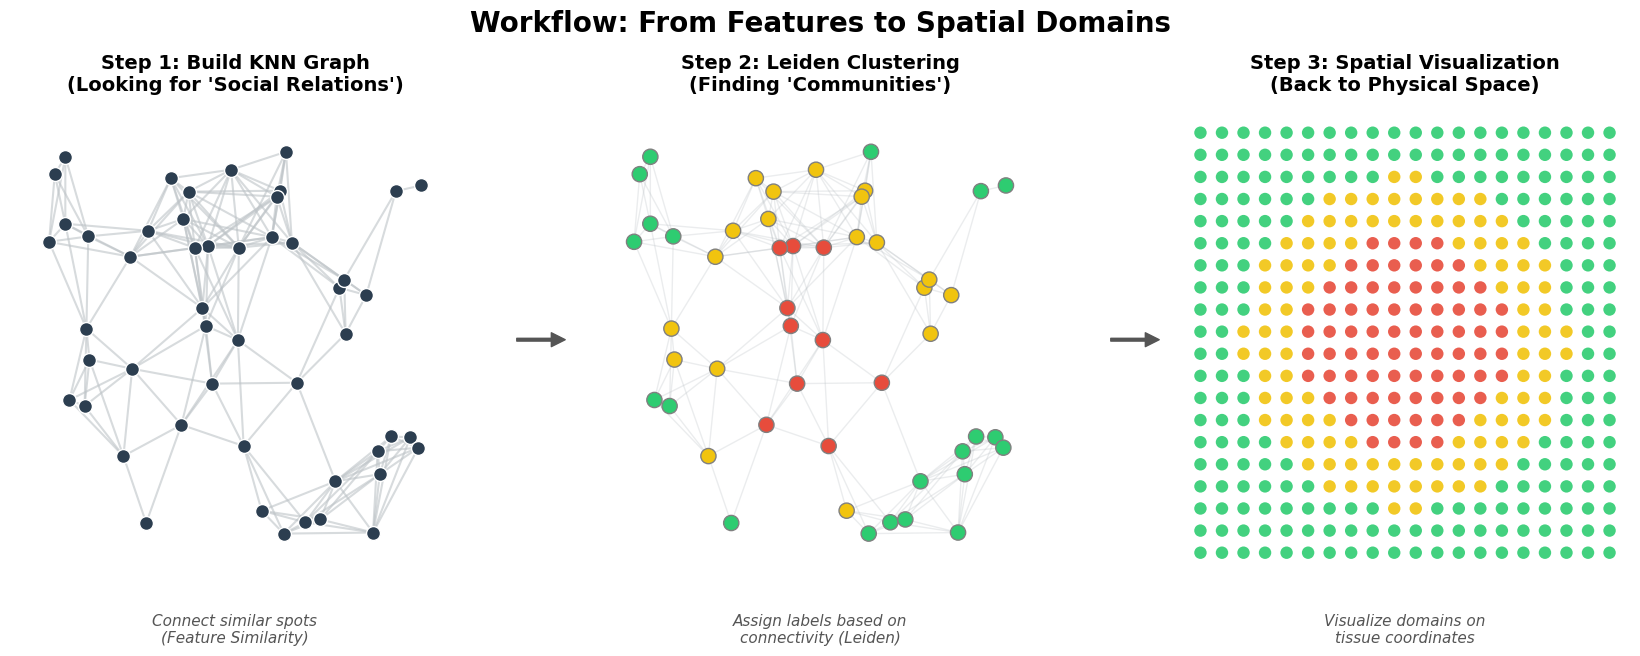

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import networkx as nx

def draw_beautiful_flowchart():
    # 设置高分辨率画布
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.3)
    
    # --- 全局配色 ---
    c_step1_edge = "#BDC3C7"  # 浅灰连线
    c_step1_node = "#2C3E50"  # 深蓝节点
    
    # 聚类配色 (模拟三个群组)
    c_cluster = ["#E74C3C", "#F1C40F", "#2ECC71"] # 红，黄，绿
    
    # --- 模拟数据生成 ---
    np.random.seed(42)
    # 生成一个随机图 (模拟 Step 1 & 2)
    G = nx.random_geometric_graph(50, 0.25)
    pos = nx.get_node_attributes(G, 'pos')
    
    # 生成空间网格数据 (模拟 Step 3)
    # 创建一个 20x20 的网格代表切片
    x = np.linspace(0, 1, 20)
    y = np.linspace(0, 1, 20)
    xv, yv = np.meshgrid(x, y)
    
    # 定义区域 (中间是圆形的肿瘤区)
    labels_grid = np.zeros(xv.shape)
    dist_from_center = np.sqrt((xv - 0.5)**2 + (yv - 0.5)**2)
    labels_grid[dist_from_center < 0.25] = 1 # Tumor (Center)
    labels_grid[dist_from_center > 0.4] = 2  # Stroma (Outer)
    # 中间过渡区默认为 0
    
    # ==========================================
    # 🎨 Step 1: KNN Graph (构建关系网)
    # ==========================================
    ax = axes[0]
    ax.set_title("Step 1: Build KNN Graph\n(Looking for 'Social Relations')", fontsize=14, fontweight='bold', pad=15)
    
    # 画线 (Edges)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=c_step1_edge, alpha=0.6, width=1.5)
    # 画点 (Nodes)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, node_color=c_step1_node, edgecolors='white')
    
    # 底部说明文字
    ax.text(0.5, -0.15, "Connect similar spots\n(Feature Similarity)", 
            transform=ax.transAxes, ha='center', fontsize=11, style='italic', color="#555")
    
    # 边框装饰
    rect = patches.FancyBboxPatch((-0.1, -0.25), 1.2, 1.35, transform=ax.transAxes, 
                                  boxstyle="round,pad=0.05", fc="none", ec="#3498DB", lw=2, ls="--")
    ax.add_patch(rect)
    ax.axis('off')

    # ==========================================
    # 🎨 Step 2: Clustering (社区发现)
    # ==========================================
    ax = axes[1]
    ax.set_title("Step 2: Leiden Clustering\n(Finding 'Communities')", fontsize=14, fontweight='bold', pad=15)
    
    # 简单的社区划分逻辑 (基于位置简单模拟，实际是基于图的)
    node_colors = []
    for node in G.nodes():
        x, y = pos[node]
        if np.sqrt((x-0.5)**2 + (y-0.5)**2) < 0.25:
            node_colors.append(c_cluster[0]) # Red group
        elif np.sqrt((x-0.5)**2 + (y-0.5)**2) > 0.4:
            node_colors.append(c_cluster[2]) # Green group
        else:
            node_colors.append(c_cluster[1]) # Yellow group
            
    # 画线 (稍微淡一点)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=c_step1_edge, alpha=0.3)
    # 画点 (带颜色！)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=120, node_color=node_colors, edgecolors='gray')
    
    # 底部说明文字
    ax.text(0.5, -0.15, "Assign labels based on\nconnectivity (Leiden)", 
            transform=ax.transAxes, ha='center', fontsize=11, style='italic', color="#555")

    # 边框装饰
    rect = patches.FancyBboxPatch((-0.1, -0.25), 1.2, 1.35, transform=ax.transAxes, 
                                  boxstyle="round,pad=0.05", fc="none", ec="#F39C12", lw=2, ls="--")
    ax.add_patch(rect)
    ax.axis('off')

    # ==========================================
    # 🎨 Step 3: Spatial Mapping (空间映射)
    # ==========================================
    ax = axes[2]
    ax.set_title("Step 3: Spatial Visualization\n(Back to Physical Space)", fontsize=14, fontweight='bold', pad=15)
    
    # 绘制类似于 10x Visium 的点阵图
    # 将 labels 映射到颜色
    cmap_custom = plt.matplotlib.colors.ListedColormap([c_cluster[1], c_cluster[0], c_cluster[2]])
    
    ax.scatter(xv, yv, c=labels_grid, cmap=cmap_custom, s=80, edgecolors='none', alpha=0.9)
    
    # 底部说明文字
    ax.text(0.5, -0.15, "Visualize domains on\ntissue coordinates", 
            transform=ax.transAxes, ha='center', fontsize=11, style='italic', color="#555")

    # 边框装饰
    rect = patches.FancyBboxPatch((-0.1, -0.25), 1.2, 1.35, transform=ax.transAxes, 
                                  boxstyle="round,pad=0.05", fc="none", ec="#2ECC71", lw=2)
    ax.add_patch(rect)
    ax.axis('off')

    # ==========================================
    # 🏹 添加箭头
    # ==========================================
    # Arrow 1 -> 2
    trans1 = plt.matplotlib.transforms.blended_transform_factory(fig.transFigure, fig.transFigure)
    arrow1 = patches.FancyArrowPatch((0.33, 0.5), (0.36, 0.5), transform=trans1, 
                                     connectionstyle="arc3,rad=0", arrowstyle="simple,tail_width=2,head_width=10,head_length=10", color="#555")
    fig.patches.append(arrow1)

    # Arrow 2 -> 3
    arrow2 = patches.FancyArrowPatch((0.66, 0.5), (0.69, 0.5), transform=trans1, 
                                     connectionstyle="arc3,rad=0", arrowstyle="simple,tail_width=2,head_width=10,head_length=10", color="#555")
    fig.patches.append(arrow2)

    plt.suptitle("Workflow: From Features to Spatial Domains", fontsize=20, fontweight='bold', y=1.05)
    plt.show()

draw_beautiful_flowchart()

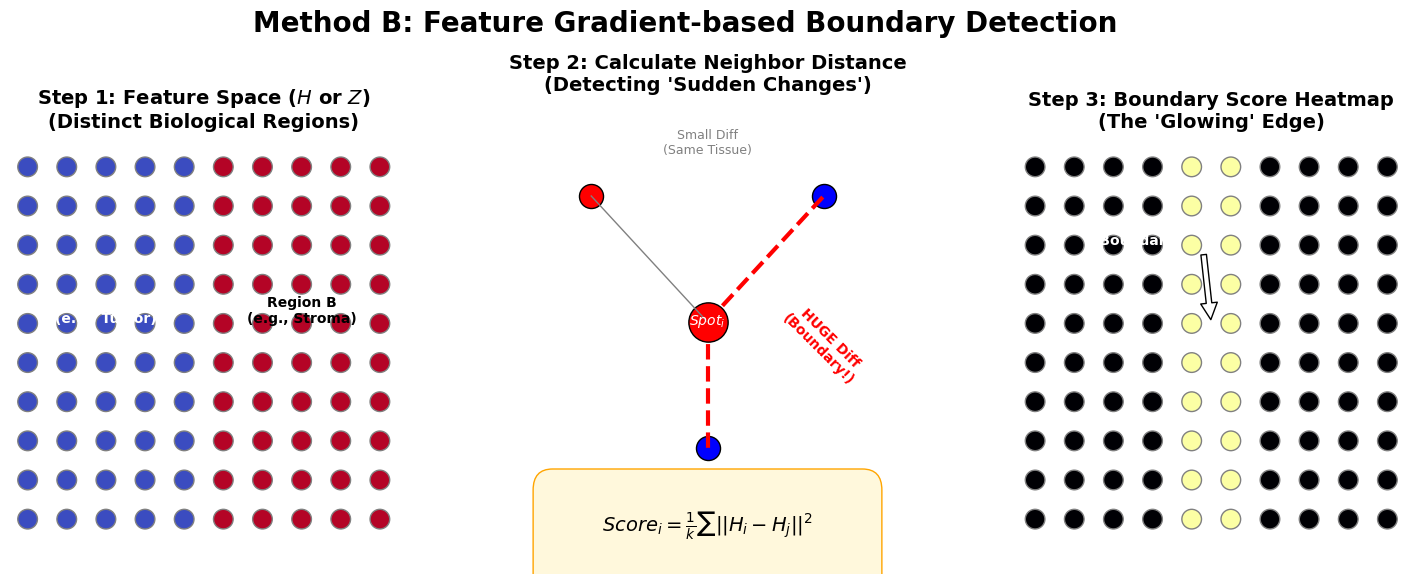

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def draw_boundary_detection_logic():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
    plt.subplots_adjust(wspace=0.3)
    
    # --- 1. 模拟数据 ---
    # 创建一个 10x10 的网格
    grid_size = 10
    x, y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    
    # 定义特征值 (Feature Value)
    # 左边是 0 (Tumor)，右边是 10 (Stroma)，中间有个突变
    features = np.zeros((grid_size, grid_size))
    features[:, 5:] = 10  # 右半部分特征值突变
    
    # 计算边界得分 (模拟梯度计算)
    # 简单的 x 方向梯度
    boundary_score = np.zeros((grid_size, grid_size))
    # 也就是第 4 列和第 5 列之间差异最大
    boundary_score[:, 4] = 5 # 边界左侧
    boundary_score[:, 5] = 5 # 边界右侧
    # 为了视觉好看，让边界线更细
    boundary_scores_visual = np.zeros((grid_size, grid_size))
    boundary_scores_visual[:, 4:6] = 1.0 # 高亮中间两列

    # --- 图 1: 特征空间 (Latent Space H) ---
    ax = axes[0]
    ax.set_title("Step 1: Feature Space ($H$ or $Z$)\n(Distinct Biological Regions)", fontsize=14, fontweight='bold', pad=15)
    
    # 使用由蓝到红的色谱
    im1 = ax.scatter(x, y, c=features, cmap='coolwarm', s=200, edgecolors='gray')
    ax.text(2, 5, "Region A\n(e.g., Tumor)", ha='center', color='white', fontweight='bold')
    ax.text(7, 5, "Region B\n(e.g., Stroma)", ha='center', color='black', fontweight='bold')
    
    ax.set_aspect('equal')
    ax.axis('off')
    
    # --- 图 2: 计算逻辑 (The Math) ---
    ax = axes[1]
    ax.set_title("Step 2: Calculate Neighbor Distance\n(Detecting 'Sudden Changes')", fontsize=14, fontweight='bold', pad=15)
    
    # 只画局部，展示计算过程
    # 画中心点
    ax.scatter([0.5], [0.5], s=800, c='red', edgecolors='black', label='Spot $i$')
    ax.text(0.5, 0.5, "$Spot_i$", ha='center', va='center', color='white', fontweight='bold')
    
    # 画邻居
    neighbors_x = [0.2, 0.8, 0.5]
    neighbors_y = [0.8, 0.8, 0.2]
    cols = ['red', 'blue', 'blue'] # 一个同类，两个异类
    
    for nx, ny, c in zip(neighbors_x, neighbors_y, cols):
        ax.scatter([nx], [ny], s=300, c=c, edgecolors='black')
        # 画连线
        style = "-" if c == 'red' else "--" 
        width = 1 if c == 'red' else 3
        color = "gray" if c == 'red' else "red"
        ax.plot([0.5, nx], [0.5, ny], linestyle=style, color=color, lw=width)
    
    ax.text(0.5, 0.9, "Small Diff\n(Same Tissue)", ha='center', fontsize=9, color='gray')
    ax.text(0.8, 0.35, "HUGE Diff\n(Boundary!)", ha='center', fontsize=10, color='red', fontweight='bold', rotation=-45)
    
    # 公式框
    eqn = r"$Score_i = \frac{1}{k} \sum ||H_i - H_j||^2$"
    rect = patches.FancyBboxPatch((0.1, -0.1), 0.8, 0.2, boxstyle="round,pad=0.05", fc="#FFF8DC", ec="orange")
    ax.add_patch(rect)
    ax.text(0.5, 0.0, eqn, ha='center', fontsize=14, color='black')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.1, 1)
    ax.axis('off')

    # --- 图 3: 边界得分热图 (Result) ---
    ax = axes[2]
    ax.set_title("Step 3: Boundary Score Heatmap\n(The 'Glowing' Edge)", fontsize=14, fontweight='bold', pad=15)
    
    # 这里的颜色代表 Score：黑色是0，黄色是高分
    im3 = ax.scatter(x, y, c=boundary_scores_visual, cmap='inferno', s=200, edgecolors='gray')
    
    # 标注
    ax.annotate("High Gradient\n(Boundary)", xy=(4.5, 5), xytext=(1.5, 7),
                arrowprops=dict(facecolor='white', shrink=0.05), color='white', fontweight='bold')
    
    ax.set_aspect('equal')
    ax.axis('off')

    plt.suptitle("Method B: Feature Gradient-based Boundary Detection", fontsize=20, fontweight='bold', y=1.05)
    plt.show()

draw_boundary_detection_logic()